# Track A: scGPT + GRN Attention Bias (M injection)

Modifies scGPT self-attention: `attn_scores = attn_scores + alpha * M_grn`

- M from CellOracle K562 GRN (1513 targets × 131 TFs)
- Aligned to scGPT's HVG vocabulary (1251 genes)
- alpha = learnable scalar, initialized 0.1
- All else identical to `S1_1b` leak-fixed baseline

In [1]:
# 1.1 Imports + GPU selection
import sys, os, subprocess

# === Auto-select last free GPU (MUST run before torch import) ===
def select_free_gpu(min_free_mb=10000):
    try:
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=index,memory.free,name', '--format=csv,nounits,noheader'],
            capture_output=True, text=True
        )
        gpus = []
        for line in result.stdout.strip().split('\n'):
            parts = line.split(',')
            gpus.append((int(parts[0]), int(parts[1]), parts[2].strip()))
        for idx, free, name in reversed(gpus):
            if free >= min_free_mb:
                os.environ["CUDA_VISIBLE_DEVICES"] = str(idx)
                print(f"Selected GPU {idx}: {name} ({free} MB free)")
                return idx
        print("WARNING: no GPU with enough free memory")
    except Exception as e:
        print(f"GPU detection failed: {e}")
    return None

select_free_gpu()

# === Now safe to import torch ===
import time, copy, random, json, warnings
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import torch
import scanpy as sc
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

import scgpt as scg
from scgpt.model import TransformerGenerator
from scgpt.tokenizer import GeneVocab
from scgpt.loss import masked_mse_loss
from scgpt.utils import set_seed, map_raw_id_to_vocab_id

matplotlib.rcParams["savefig.transparent"] = False
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Verify actual GPU in use ===
if device.type == "cuda":
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory  / 1e9:.1f} GB")
    print(f"  CUDA arch: {torch.cuda.get_device_capability(0)}")
else:
    print("WARNING: running on CPU")

Selected GPU 7: Tesla V100-SXM2-32GB (32501 MB free)


/conda_envs/scgpt/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/conda_envs/scgpt/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/conda_envs/scgpt/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/conda_envs/scgpt/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warn

Device: Tesla V100-SXM2-32GB
  Memory: 34.1 GB
  CUDA arch: (7, 0)


In [3]:
# 1.2 Reproducibility
def setup_environment(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    sc.settings.seed = seed
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

setup_environment(42)

In [4]:
# 2.1 Paths — edit these
data_path = "../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad"
model_dir = "../../model_checkpoints/scGPT_human"

# CellOracle M matrix outputs
celloracle_dir = "../CellOracle/celloracle_grn_20260305_221104"  # <-- your run dir
M_MATRIX_CSV = f"{celloracle_dir}/K562_GRN_M_matrix.csv"
M_TARGET_GENES = f"{celloracle_dir}/K562_GRN_M_target_genes.csv"
M_SOURCE_TFS = f"{celloracle_dir}/K562_GRN_M_source_TFs.csv"

In [5]:
# 2.2 Hyperparameters (identical to S1_1b except where noted)
embsize = 128
d_hid = 512
nlayers = 4
nhead = 4
n_layers_cls = 3

epochs = 15
lr = 1e-4
batch_size = 256 #716
eval_batch_size = 256 #384
schedule_interval = 1
early_stop = 10
dropout = 0.2
amp = True

# GRN bias
ALPHA_INIT = 0.1        # initial value for learnable alpha
M_NORMALIZE = True      # row-normalize M before injection

MLM = True
CLS = False
CCE = False
MVC = False
ECS = False

pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
pad_value = 0
pert_pad_id = 0
include_zero_gene = "all"
max_seq_len = 1536
log_interval = 50

save_dir = Path(f"./save/dev_perturb_norman_grn_bias-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"Save directory: {save_dir}")

logger = scg.logger
scg.utils.add_file_handler(logger, save_dir / "run.log")

Save directory: save/dev_perturb_norman_grn_bias-Mar06-12-39


## 3. Data Loading & Preprocessing (same as S1_1b)

In [6]:
# 3.1 Load + normalize
adata = sc.read_h5ad(data_path)
adata.obs['split'] = adata.obs['gears_split']
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

if 'gene_name' in adata.var:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()
print(f"Genes: {adata.var_names[:5].tolist()}")

Genes: ['RP11-34P13.8', 'RP11-54O7.3', 'SAMD11', 'PERM1', 'HES4']


In [7]:
# 3.2 HVG on train only (leak-fixed)
train_adata = adata[adata.obs['split'] == 'train'].copy()
train_perturbed_genes = set()
for condition in train_adata.obs['condition'].unique():
    if condition != 'ctrl':
        for p in condition.split('+'):
            if p != 'ctrl':
                train_perturbed_genes.add(p)

sc.pp.highly_variable_genes(train_adata, n_top_genes=1200, flavor='seurat', subset=False)
hvg_genes = set(train_adata.var[train_adata.var['highly_variable']].index)
hvg_genes.update(train_perturbed_genes & set(adata.var_names))
adata.var['highly_variable'] = adata.var_names.isin(hvg_genes)
adata = adata[:, adata.var['highly_variable']].copy()
print(f"Features: {adata.shape[1]} genes")

Features: 1251 genes


In [8]:
# 3.3 Control pool (train only)
ctrl_adata = adata[
    (adata.obs['condition'] == 'ctrl') & (adata.obs['split'] == 'train')
].copy()
global_ctrl_X = ctrl_adata.X.toarray() if hasattr(ctrl_adata.X, "toarray") else ctrl_adata.X
print(f"Control pool: {global_ctrl_X.shape[0]} cells")

Control pool: 7353 cells


## 4. Load & Align GRN M Matrix

In [9]:
# 4.1 Load CellOracle M matrix
M_df = pd.read_csv(M_MATRIX_CSV, index_col=0)
print(f"Raw M: {M_df.shape} (targets × TFs)")
print(f"  Non-zero: {(M_df != 0).sum().sum()}, sparsity: {1 - (M_df != 0).sum().sum() / M_df.size:.3f}")
print(f"  Coef range: [{M_df.values.min():.4f}, {M_df.values.max():.4f}]")

Raw M: (1513, 131) (targets × TFs)
  Non-zero: 36141, sparsity: 0.818
  Coef range: [-0.3454, 0.5199]


In [10]:
# 4.2 Align M to scGPT gene vocabulary
#
# M_df: rows = target genes, cols = source TFs
# scGPT genes: adata.var_names (1251 HVGs)
# 
# Build M_aligned: (n_genes × n_genes) where
#   M_aligned[i, j] = regulatory weight of gene_j -> gene_i
#   (i.e., row = target, col = source — same as attention convention:
#    attention[query_i, key_j] biased toward j->i regulation)

scgpt_genes = adata.var_names.tolist()
n_genes = len(scgpt_genes)
gene_to_idx = {g: i for i, g in enumerate(scgpt_genes)}

M_targets = set(M_df.index)
M_tfs = set(M_df.columns)

target_overlap = M_targets & set(scgpt_genes)
tf_overlap = M_tfs & set(scgpt_genes)
print(f"Target genes in scGPT vocab: {len(target_overlap)}/{len(M_targets)}")
print(f"Source TFs in scGPT vocab:   {len(tf_overlap)}/{len(M_tfs)}")

# Build dense aligned matrix
M_aligned = np.zeros((n_genes, n_genes), dtype=np.float32)
n_edges_mapped = 0

for tf in M_df.columns:
    if tf not in gene_to_idx:
        continue
    j = gene_to_idx[tf]  # source column
    for target in M_df.index:
        if target not in gene_to_idx:
            continue
        val = M_df.loc[target, tf]
        if val != 0:
            i = gene_to_idx[target]  # target row
            M_aligned[i, j] = val
            n_edges_mapped += 1

print(f"Edges mapped to scGPT space: {n_edges_mapped}")
print(f"M_aligned shape: {M_aligned.shape}, non-zero: {(M_aligned != 0).sum()}")
print(f"Density in aligned space: {(M_aligned != 0).sum() / M_aligned.size:.6f}")

Target genes in scGPT vocab: 345/1513
Source TFs in scGPT vocab:   52/131
Edges mapped to scGPT space: 3509
M_aligned shape: (1251, 1251), non-zero: 3509
Density in aligned space: 0.002242


In [11]:
# 4.3 Normalize M (optional but recommended)
# Row-normalize: each target gene's incoming regulatory weights sum to ~1
# This prevents M magnitude from dominating attention logits

if M_NORMALIZE:
    row_norms = np.abs(M_aligned).sum(axis=1, keepdims=True)
    row_norms = np.where(row_norms > 0, row_norms, 1.0)  # avoid /0 for genes with no regulation
    M_aligned = M_aligned / row_norms
    print(f"Row-normalized M: abs row sums in [{np.abs(M_aligned).sum(1).min():.3f}, {np.abs(M_aligned).sum(1).max():.3f}]")

M_tensor = torch.tensor(M_aligned, dtype=torch.float32, device=device)
print(f"M_tensor: {M_tensor.shape}, device={M_tensor.device}")

# Save aligned M for reproducibility
np.save(save_dir / "M_aligned.npy", M_aligned)
print(f"Saved M_aligned.npy")

Row-normalized M: abs row sums in [0.000, 1.000]
M_tensor: torch.Size([1251, 1251]), device=cuda:0
Saved M_aligned.npy


## 5. GRN-Biased Model

In [12]:
# 5.1 Monkey-patch attention to inject GRN bias
#
# scGPT's TransformerGenerator uses FlashTransformerEncoderLayer or
# standard nn.TransformerEncoderLayer. We patch the forward pass of
# each encoder layer's self-attention to add M_grn bias.
#
# Strategy: wrap model with a GRNBiasWrapper that:
#   1. Holds learnable alpha (scalar)
#   2. Hooks into attention via attn_mask argument
#
# Since scGPT passes src_key_padding_mask through the transformer,
# we inject M as an additive attention mask.

class GRNBiasedTransformerGenerator(nn.Module):
    """Wraps TransformerGenerator, adding GRN attention bias."""
    
    def __init__(self, base_model: TransformerGenerator, M_grn: torch.Tensor, alpha_init: float = 0.1):
        super().__init__()
        self.base_model = base_model
        # M_grn: (n_genes, n_genes) — fixed regulatory prior
        self.register_buffer('M_grn', M_grn)
        # Learnable scaling factor
        self.alpha = nn.Parameter(torch.tensor(alpha_init, dtype=torch.float32))
        # Per-head learnable gate (optional — start with shared alpha)
        # self.head_gates = nn.Parameter(torch.ones(nhead) * alpha_init)
    
    def forward(self, *args, **kwargs):
        # Intercept: inject M_grn as attn_mask
        # scGPT's transformer_encoder expects: src, src_key_padding_mask
        # We add attn_mask = alpha * M_grn (broadcast over batch & heads)
        #
        # The base model calls self.transformer_encoder internally.
        # We need to patch deeper. See cell 5.2 for the actual hook.
        return self.base_model(*args, **kwargs)

print("GRNBiasedTransformerGenerator defined")

GRNBiasedTransformerGenerator defined


In [13]:
# 5.2 Direct attention hook — patches each TransformerEncoderLayer
#
# IMPORTANT: wrapper must delegate attribute lookups (batch_first, num_heads, etc.)
# to the original nn.MultiheadAttention, or TransformerEncoderLayer will crash.

class GRNAttentionBias(nn.Module):
    """Wraps nn.MultiheadAttention to inject GRN bias into attention scores.
    
    attn_output = softmax((Q @ K^T)/sqrt(d) + alpha * M_grn[gene_indices]) @ V
    """
    
    def __init__(self, original_attn: nn.MultiheadAttention, M_grn: torch.Tensor, alpha: nn.Parameter):
        super().__init__()
        self.original_attn = original_attn
        self.M_grn = M_grn
        self.alpha = alpha
    
    def __getattr__(self, name):
        """Delegate missing attrs (batch_first, num_heads, etc.) to wrapped attn."""
        try:
            return super().__getattr__(name)
        except AttributeError:
            original = self.__dict__.get('_modules', {}).get('original_attn')
            if original is not None:
                return getattr(original, name)
            raise
    
    def forward(self, query, key, value, key_padding_mask=None, need_weights=False, attn_mask=None, **kwargs):
        seq_len = query.size(0)  # (seq_len, batch, embed)
        
        if hasattr(self, '_current_gene_indices') and self._current_gene_indices is not None:
            idx = self._current_gene_indices
            grn_bias = self.alpha * self.M_grn[idx][:, idx]
        else:
            grn_bias = self.alpha * self.M_grn[:seq_len, :seq_len]
        
        if attn_mask is None:
            attn_mask = grn_bias
        else:
            attn_mask = attn_mask + grn_bias
        
        return self.original_attn(
            query, key, value,
            key_padding_mask=key_padding_mask,
            need_weights=need_weights,
            attn_mask=attn_mask,
            **kwargs
        )

print("GRNAttentionBias wrapper defined (with __getattr__ delegation)")

GRNAttentionBias wrapper defined (with __getattr__ delegation)


In [14]:
# 5.3 Build model, load pretrained weights, patch attention

# --- Load vocabulary ---
load_param_prefixs = ["encoder", "value_encoder", "transformer_encoder"]
model_file = Path(model_dir) / "best_model.pt"
vocab_file = Path(model_dir) / "vocab.json"

vocab = GeneVocab.from_file(vocab_file)
for s in special_tokens:
    if s not in vocab:
        vocab.append_token(s)

adata.var["id_in_vocab"] = [1 if gene in vocab else -1 for gene in adata.var_names]
n_matched = np.sum(np.array(adata.var["id_in_vocab"]) >= 0)
print(f"Vocab match: {n_matched}/{adata.shape[1]}")

genes = adata.var_names.tolist()
gene_ids = np.array([vocab[gene] if gene in vocab else vocab["<pad>"] for gene in genes], dtype=int)
n_genes = len(genes)
ntokens = len(vocab)

# --- Build base model ---
model = TransformerGenerator(
    ntokens, embsize, nhead, d_hid, nlayers,
    nlayers_cls=n_layers_cls, n_cls=1, vocab=vocab, dropout=dropout,
    pad_token=pad_token, pad_value=pad_value, pert_pad_id=pert_pad_id,
    use_fast_transformer=False,
)

# --- Load pretrained ---
pretrained_dict = torch.load(model_file)
model_dict = model.state_dict()
filtered_dict = {
    k: v for k, v in pretrained_dict.items()
    if any(k.startswith(prefix) for prefix in load_param_prefixs)
    and k in model_dict and v.shape == model_dict[k].shape
}
model.load_state_dict(filtered_dict, strict=False)
print(f"Loaded {len(filtered_dict)} pretrained tensors")

Vocab match: 1146/1251
Loaded 4 pretrained tensors


In [15]:
# 5.4 Patch self-attention layers with GRN bias

# Learnable alpha — shared across all layers and heads
alpha_param = nn.Parameter(torch.tensor(ALPHA_INIT, dtype=torch.float32))

# Store references to all patched attention modules (for setting gene indices)
patched_attns = []

encoder = model.transformer_encoder
for layer_idx, layer in enumerate(encoder.layers):
    original_attn = layer.self_attn
    wrapped = GRNAttentionBias(original_attn, M_tensor, alpha_param)
    layer.self_attn = wrapped
    patched_attns.append(wrapped)
    print(f"  Layer {layer_idx}: patched self_attn")

# Register alpha as a model parameter so optimizer picks it up
model.alpha_grn = alpha_param
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,} (+1 for alpha)")
print(f"Alpha init: {model.alpha_grn.item():.3f}")

  Layer 0: patched self_attn
  Layer 1: patched self_attn
  Layer 2: patched self_attn
  Layer 3: patched self_attn

Total parameters: 8,679,940 (+1 for alpha)
Alpha init: 0.100


In [16]:
# 5.5 Helper: set current gene indices on all patched attention layers
def set_gene_indices(gene_indices):
    """Tell attention wrappers which gene subset is being used this batch."""
    for attn in patched_attns:
        attn._current_gene_indices = gene_indices

print("set_gene_indices helper defined")

set_gene_indices helper defined


## 6. Dataset & DataLoader (identical to S1_1b)

In [17]:
# 6.1 Dataset
class scGPTPerturbDataset(Dataset):
    def __init__(self, adata, ctrl_X, split="train"):
        self.adata = adata[adata.obs['split'] == split].copy()
        self.X = self.adata.X.toarray() if hasattr(self.adata.X, "toarray") else self.adata.X
        self.conditions = self.adata.obs['condition'].values
        self.gene_names = self.adata.var_names.tolist()
        self.gene_to_idx = {gene: i for i, gene in enumerate(self.gene_names)}
        self.ctrl_X = ctrl_X

    def __len__(self):
        return len(self.adata)

    def __getitem__(self, idx):
        target_expr = torch.tensor(self.X[idx], dtype=torch.float32)
        condition = self.conditions[idx]
        pert_flags = torch.zeros(len(self.gene_names), dtype=torch.long)
        if condition != "ctrl":
            for p in condition.split('+'):
                if p != "ctrl" and p in self.gene_to_idx:
                    pert_flags[self.gene_to_idx[p]] = 1
        random_ctrl_idx = np.random.randint(0, len(self.ctrl_X))
        ori_expr = torch.tensor(self.ctrl_X[random_ctrl_idx], dtype=torch.float32)
        return ori_expr, pert_flags, target_expr, condition

train_dataset = scGPTPerturbDataset(adata, global_ctrl_X, split="train")
val_dataset = scGPTPerturbDataset(adata, global_ctrl_X, split="val")
test_dataset = scGPTPerturbDataset(adata, global_ctrl_X, split="test")

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=eval_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=eval_batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 47192, Val: 11196, Test: 30969


## 7. Training Loop (with GRN bias)

In [18]:
# 7.1 Training utilities
criterion = masked_mse_loss
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, schedule_interval, gamma=0.9)
scaler = torch.cuda.amp.GradScaler(enabled=amp)

def train_epoch(model, train_loader):
    model.train()
    total_loss = 0.0
    start_time = time.time()
    num_batches = len(train_loader)

    for batch_idx, (ori_expr, pert_flags, target_expr, _) in enumerate(train_loader):
        bs = ori_expr.size(0)
        ori_gene_values = ori_expr.to(device)
        pert_flags = pert_flags.to(device)
        target_gene_values = target_expr.to(device)

        input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
        if len(input_gene_ids) > max_seq_len:
            input_gene_ids = torch.randperm(len(input_gene_ids), device=device)[:max_seq_len]
        
        # ---- GRN BIAS: tell attention layers which genes are active ----
        set_gene_indices(input_gene_ids)

        input_values = ori_gene_values[:, input_gene_ids]
        input_pert_flags = pert_flags[:, input_gene_ids]
        target_values = target_gene_values[:, input_gene_ids]

        mapped_ids = map_raw_id_to_vocab_id(input_gene_ids, gene_ids).repeat(bs, 1).to(device)
        src_key_padding_mask = torch.zeros_like(input_values, dtype=torch.bool, device=device)

        with torch.cuda.amp.autocast(enabled=amp):
            output_dict = model(
                mapped_ids, input_values, input_pert_flags,
                src_key_padding_mask=src_key_padding_mask,
                CLS=CLS, CCE=CCE, MVC=MVC, ECS=ECS,
            )
            output_values = output_dict["mlm_output"]
            masked_positions = torch.ones_like(input_values, dtype=torch.bool)
            loss = criterion(output_values, target_values, masked_positions)

        model.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        if batch_idx % log_interval == 0 and batch_idx > 0:
            avg_loss = total_loss / log_interval
            ms = (time.time() - start_time) * 1000 / log_interval
            logger.info(
                f"| batch {batch_idx:3d}/{num_batches:3d} | ms/batch {ms:5.1f} | "
                f"loss {avg_loss:.4f} | alpha {model.alpha_grn.item():.4f}"
            )
            total_loss = 0.0
            start_time = time.time()

In [19]:
# 7.2 Evaluation
def eval_perturb(loader, model, device):
    model.eval()
    pert_cat, pred, truth = [], [], []
    input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
    mapped_base = map_raw_id_to_vocab_id(input_gene_ids, gene_ids).to(device)
    
    set_gene_indices(input_gene_ids)

    with torch.no_grad():
        for ori_expr, pert_flags, target_expr, conditions in loader:
            bs = ori_expr.size(0)
            input_values = ori_expr.to(device)
            input_pert_flags = pert_flags.to(device)
            target_values = target_expr.to(device)
            mapped_ids = mapped_base.repeat(bs, 1)
            src_key_padding_mask = torch.zeros_like(input_values, dtype=torch.bool, device=device)

            with torch.cuda.amp.autocast(enabled=amp):
                output_dict = model(
                    mapped_ids, input_values, input_pert_flags,
                    src_key_padding_mask=src_key_padding_mask,
                    CLS=CLS, CCE=CCE, MVC=MVC, ECS=ECS,
                )
            pert_cat.extend(conditions)
            pred.append(output_dict["mlm_output"].cpu().numpy())
            truth.append(target_values.cpu().numpy())

    return {
        "pert_cat": np.array(pert_cat),
        "pred": np.concatenate(pred).astype(np.float64),
        "truth": np.concatenate(truth).astype(np.float64),
    }

def compute_metrics_allgenes(res_dict):
    pert_cats = res_dict['pert_cat']
    preds = res_dict['pred']
    truths = res_dict['truth']
    corrs = []
    for pert in np.unique(pert_cats):
        if pert == 'ctrl':
            continue
        idx = np.where(pert_cats == pert)[0]
        if len(idx) == 0:
            continue
        r, _ = pearsonr(preds[idx].mean(axis=0), truths[idx].mean(axis=0))
        if not np.isnan(r):
            corrs.append(r)
    return {"pearson_all_genes": np.mean(corrs)}

In [20]:
# 7.3 Training loop
best_val_corr = 0
best_model_epoch = 0
patience = 0
alpha_history = []
eval_batch_size = 256  # Fix 4: reduced from 384

# Rebuild valid loader with reduced batch size
valid_loader = DataLoader(val_dataset, batch_size=eval_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=eval_batch_size, shuffle=False)

for epoch in range(1, epochs + 1):
    t0 = time.time()
    train_epoch(model, train_loader)
    
    torch.cuda.empty_cache()  # Fix 2: free fragmented memory before eval
    
    val_res = eval_perturb(valid_loader, model, device)
    val_metrics = compute_metrics_allgenes(val_res)
    val_score = val_metrics["pearson_all_genes"]
    cur_alpha = model.alpha_grn.item()
    alpha_history.append(cur_alpha)
    
    logger.info(
        f"Epoch {epoch:2d} | {time.time()-t0:.0f}s | "
        f"val PCC(all): {val_score:.4f} | alpha: {cur_alpha:.4f}"
    )

    if val_score > best_val_corr:
        best_val_corr = val_score
        # Fix 1: save to disk instead of copy.deepcopy
        torch.save(model.state_dict(), save_dir / "best_model.pt")
        best_model_epoch = epoch
        logger.info(f"  -> New best (PCC={val_score:.4f}), saved epoch {epoch}")
        patience = 0
    else:
        patience += 1
        if patience >= early_stop:
            logger.info(f"Early stopping at epoch {epoch}")
            break
    scheduler.step()

# Reload best model from disk
model.load_state_dict(torch.load(save_dir / "best_model.pt"))
best_model = model
print(f"Best model loaded (epoch {best_model_epoch}, val PCC={best_val_corr:.4f})")

scGPT - INFO - | batch  50/185 | ms/batch 978.6 | loss 0.2069 | alpha 0.1035
scGPT - INFO - | batch 100/185 | ms/batch 944.9 | loss 0.1717 | alpha 0.1044
scGPT - INFO - | batch 150/185 | ms/batch 945.0 | loss 0.1532 | alpha 0.1022
scGPT - INFO - Epoch  1 | 188s | val PCC(all): 0.9718 | alpha: 0.1020
scGPT - INFO -   -> New best (PCC=0.9718), saved epoch 1
scGPT - INFO - | batch  50/185 | ms/batch 963.7 | loss 0.1300 | alpha 0.1025
scGPT - INFO - | batch 100/185 | ms/batch 944.7 | loss 0.1256 | alpha 0.1030
scGPT - INFO - | batch 150/185 | ms/batch 944.8 | loss 0.1244 | alpha 0.1040
scGPT - INFO - Epoch  2 | 188s | val PCC(all): 0.9727 | alpha: 0.1044
scGPT - INFO -   -> New best (PCC=0.9727), saved epoch 2
scGPT - INFO - | batch  50/185 | ms/batch 964.2 | loss 0.1256 | alpha 0.1055
scGPT - INFO - | batch 100/185 | ms/batch 945.7 | loss 0.1243 | alpha 0.1066
scGPT - INFO - | batch 150/185 | ms/batch 945.8 | loss 0.1242 | alpha 0.1078
scGPT - INFO - Epoch  3 | 188s | val PCC(all): 0.9727

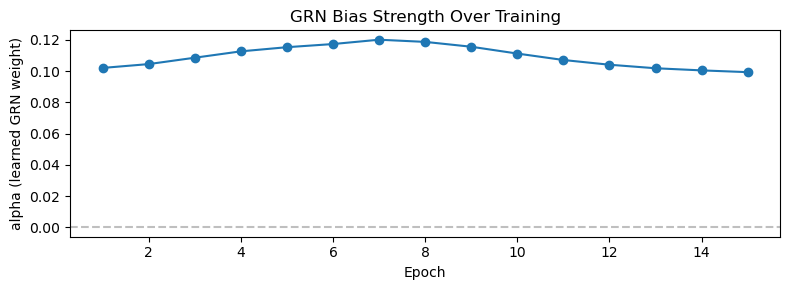

Final alpha: 0.0993


In [21]:
# 7.4 Alpha trajectory
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, len(alpha_history)+1), alpha_history, 'o-')
ax.set_xlabel('Epoch')
ax.set_ylabel('alpha (learned GRN weight)')
ax.set_title('GRN Bias Strength Over Training')
ax.axhline(0, ls='--', c='gray', alpha=0.5)
plt.tight_layout()
plt.savefig(save_dir / "alpha_trajectory.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Final alpha: {alpha_history[-1]:.4f}")

## 8. Test Evaluation (PCC top-20 DE)

In [22]:
# 8.1 Metrics
def compute_metrics_top20de(res_dict, ctrl_mean):
    pert_cats = res_dict['pert_cat']
    preds = res_dict['pred']
    truths = res_dict['truth']
    per_pert = {}
    corrs_top20, corrs_all, mse_top20 = [], [], []
    
    for pert in np.unique(pert_cats):
        if pert == 'ctrl':
            continue
        idx = np.where(pert_cats == pert)[0]
        if len(idx) < 2:
            continue
        mean_pred = preds[idx].mean(axis=0)
        mean_truth = truths[idx].mean(axis=0)
        pred_delta = mean_pred - ctrl_mean
        truth_delta = mean_truth - ctrl_mean
        top20_idx = np.argsort(np.abs(truth_delta))[-20:]
        
        r_top20, _ = pearsonr(pred_delta[top20_idx], truth_delta[top20_idx])
        r_all, _ = pearsonr(pred_delta, truth_delta)
        mse = np.mean((pred_delta[top20_idx] - truth_delta[top20_idx]) ** 2)
        
        if not np.isnan(r_top20):
            corrs_top20.append(r_top20)
            corrs_all.append(r_all)
            mse_top20.append(mse)
            per_pert[pert] = {
                "pcc_top20": r_top20, "pcc_all": r_all,
                "mse_top20": mse, "n_cells": len(idx),
            }
    
    return {
        "mean_pcc_top20": np.mean(corrs_top20),
        "median_pcc_top20": np.median(corrs_top20),
        "std_pcc_top20": np.std(corrs_top20),
        "mean_pcc_all": np.mean(corrs_all),
        "mean_mse_top20": np.mean(mse_top20),
        "n_perturbations": len(corrs_top20),
        "per_pert": per_pert,
    }

In [23]:
# 8.2 Run test evaluation
ctrl_cells = adata[adata.obs['condition'] == 'ctrl']
ctrl_X = ctrl_cells.X.toarray() if hasattr(ctrl_cells.X, "toarray") else ctrl_cells.X
ctrl_mean = ctrl_X.mean(axis=0)

test_res = eval_perturb(test_loader, best_model, device)
metrics = compute_metrics_top20de(test_res, ctrl_mean)

print("=" * 60)
print("TRACK A RESULTS: scGPT + GRN Attention Bias")
print("=" * 60)
print(f"PCC (top-20 DE, mean):   {metrics['mean_pcc_top20']:.4f}")
print(f"PCC (top-20 DE, median): {metrics['median_pcc_top20']:.4f}")
print(f"PCC (top-20 DE, std):    {metrics['std_pcc_top20']:.4f}")
print(f"MSE (top-20 DE):         {metrics['mean_mse_top20']:.4f}")
print(f"N perturbations:         {metrics['n_perturbations']}")
print(f"Learned alpha:           {best_model.alpha_grn.item():.4f}")
print()
print("BASELINE COMPARISON (S1_1b leak-fixed):")
print(f"  PCC (top-20 DE): 0.5411 (mean), 0.6395 (median)")
print(f"  MSE (top-20 DE): 0.6092")

TRACK A RESULTS: scGPT + GRN Attention Bias
PCC (top-20 DE, mean):   0.5379
PCC (top-20 DE, median): 0.5737
PCC (top-20 DE, std):    0.3645
MSE (top-20 DE):         0.4824
N perturbations:         114
Learned alpha:           0.0993

BASELINE COMPARISON (S1_1b leak-fixed):
  PCC (top-20 DE): 0.5411 (mean), 0.6395 (median)
  MSE (top-20 DE): 0.6092


In [24]:
# 8.3 Save results
save_metrics = {k: v for k, v in metrics.items() if k != 'per_pert'}
save_metrics['learned_alpha'] = best_model.alpha_grn.item()
save_metrics['alpha_history'] = alpha_history
with open(save_dir / "test_metrics.json", "w") as f:
    json.dump(save_metrics, f, indent=2)

results_df = pd.DataFrame([
    {"perturbation": pert, "model": "scGPT_grn_bias", **m}
    for pert, m in metrics['per_pert'].items()
])
results_df.to_csv(save_dir / "per_perturbation_results.csv", index=False)
print(f"Saved {len(results_df)} perturbation results")

Saved 114 perturbation results


## 9. Head-to-Head Comparison

In [25]:
# 9.1 Load baseline results for comparison
import glob

baseline_dirs = sorted(glob.glob("./save/dev_perturb_norman_leakfix-*/"))
if baseline_dirs:
    baseline_csv = Path(baseline_dirs[-1]) / "per_perturbation_results.csv"
    if baseline_csv.exists():
        baseline_df = pd.read_csv(baseline_csv)
        print(f"Loaded baseline: {baseline_csv} ({len(baseline_df)} perts)")
    else:
        baseline_df = None
        print(f"No baseline CSV found")
else:
    baseline_df = None
    print("No baseline run found")

Loaded baseline: save/dev_perturb_norman_leakfix-Mar05-20-28/per_perturbation_results.csv (114 perts)


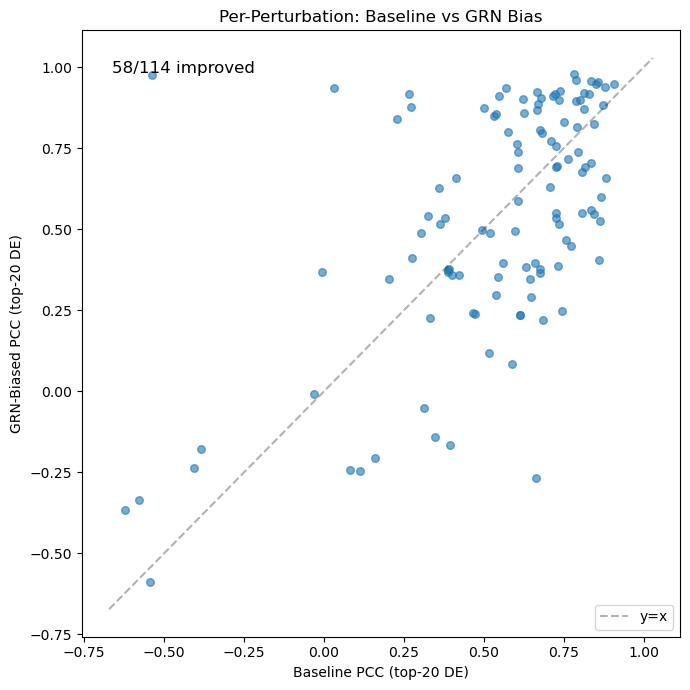

Mean delta PCC: -0.0032
Median delta:   +0.0073
Improved/Total: 58/114

Top 5 most improved:
  CEBPB+CEBPA                    0.783 -> 0.979 (+0.195)
  CEBPB+MAPK1                    -0.537 -> 0.976 (+1.513)
  BCL2L11+TGFBR2                 0.787 -> 0.960 (+0.173)
  PTPN12+ZBTB25                  0.836 -> 0.957 (+0.122)
  CBL+PTPN12                     0.857 -> 0.953 (+0.096)


In [26]:
# 9.2 Scatter: baseline vs GRN-biased per perturbation
if baseline_df is not None:
    merged = results_df.merge(
        baseline_df[['perturbation', 'pcc_top20']],
        on='perturbation', suffixes=('_grn', '_baseline')
    )
    
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(merged['pcc_top20_baseline'], merged['pcc_top20_grn'], alpha=0.6, s=30)
    lims = [min(merged[['pcc_top20_baseline','pcc_top20_grn']].min()) - 0.05,
            max(merged[['pcc_top20_baseline','pcc_top20_grn']].max()) + 0.05]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='y=x')
    ax.set_xlabel('Baseline PCC (top-20 DE)')
    ax.set_ylabel('GRN-Biased PCC (top-20 DE)')
    ax.set_title('Per-Perturbation: Baseline vs GRN Bias')
    ax.legend()
    
    n_improved = (merged['pcc_top20_grn'] > merged['pcc_top20_baseline']).sum()
    ax.text(0.05, 0.95, f"{n_improved}/{len(merged)} improved",
            transform=ax.transAxes, va='top', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(save_dir / "baseline_vs_grn.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Delta stats
    delta = merged['pcc_top20_grn'] - merged['pcc_top20_baseline']
    print(f"Mean delta PCC: {delta.mean():+.4f}")
    print(f"Median delta:   {delta.median():+.4f}")
    print(f"Improved/Total: {n_improved}/{len(merged)}")
    print(f"\nTop 5 most improved:")
    for _, row in merged.nlargest(5, 'pcc_top20_grn')[[  # fix: sort by delta
        'perturbation','pcc_top20_baseline','pcc_top20_grn'
    ]].iterrows():
        d = row['pcc_top20_grn'] - row['pcc_top20_baseline']
        print(f"  {row['perturbation']:30s} {row['pcc_top20_baseline']:.3f} -> {row['pcc_top20_grn']:.3f} ({d:+.3f})")
else:
    print("Skipping comparison — run S1_1b first")

## 10. Ablation: Alpha=0 Sanity Check

If alpha converges to ~0, the GRN prior provides no benefit.
Key diagnostic: does alpha stay positive and does it improve on non-additive perturbations?

In [27]:
# 10.1 Check alpha behavior
print(f"Alpha trajectory: {[f'{a:.4f}' for a in alpha_history]}")
print(f"Final alpha: {alpha_history[-1]:.4f}")

if abs(alpha_history[-1]) < 0.01:
    print("\nWARNING: alpha ~= 0 -> GRN bias is not contributing.")
    print("Possible causes:")
    print("  1. M normalization too aggressive")
    print("  2. GRN prior not informative for this gene set")
    print("  3. alpha_init too small (try 0.5 or 1.0)")
    print("  4. Need per-head or per-layer alpha")
elif alpha_history[-1] > 2.0:
    print("\nWARNING: alpha very large -> may be overfitting to GRN structure.")
    print("Consider adding L2 penalty on alpha.")
else:
    print(f"\nalpha in reasonable range [{min(alpha_history):.3f}, {max(alpha_history):.3f}]")

Alpha trajectory: ['0.1020', '0.1044', '0.1085', '0.1126', '0.1152', '0.1172', '0.1200', '0.1186', '0.1155', '0.1112', '0.1070', '0.1040', '0.1018', '0.1004', '0.0993']
Final alpha: 0.0993

alpha in reasonable range [0.099, 0.120]


In [28]:
# 10.2 Coverage analysis: which test perturbations have GRN edges?
per_pert = metrics['per_pert']
M_tfs_in_vocab = set(M_df.columns) & set(genes)

covered, uncovered = [], []
for pert in per_pert:
    pert_genes = set(p for p in pert.split('+') if p != 'ctrl')
    if pert_genes & M_tfs_in_vocab:
        covered.append((pert, per_pert[pert]['pcc_top20']))
    else:
        uncovered.append((pert, per_pert[pert]['pcc_top20']))

print(f"Perturbations with GRN coverage:    {len(covered)} (mean PCC: {np.mean([c[1] for c in covered]):.3f})")
print(f"Perturbations without GRN coverage:  {len(uncovered)} (mean PCC: {np.mean([c[1] for c in uncovered]):.3f})")
print(f"\nExpected: GRN-covered perturbations benefit more from M injection")

Perturbations with GRN coverage:    28 (mean PCC: 0.704)
Perturbations without GRN coverage:  86 (mean PCC: 0.484)

Expected: GRN-covered perturbations benefit more from M injection


In [29]:
# 10.3 Final output listing
print("=" * 50)
print("OUTPUT FILES")
print("=" * 50)
for f in sorted(os.listdir(save_dir)):
    size = os.path.getsize(save_dir / f) / 1e6
    print(f"  {f} ({size:.1f} MB)")

OUTPUT FILES
  .ipynb_checkpoints (0.0 MB)
  M_aligned.npy (6.3 MB)
  alpha_trajectory.png (0.0 MB)
  baseline_vs_grn.png (0.1 MB)
  best_model.pt (34.8 MB)
  per_perturbation_results.csv (0.0 MB)
  run.log (0.0 MB)
  test_metrics.json (0.0 MB)
